# Epic Mustache Detector v2
Transfer learning med MobileNetV2 för bättre generalisering.

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


## Ladda dataset

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
DATA_DIR = "data/epic_dataset_auto"  # byt till "data/epic_dataset" för att gå tillbaka

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

print("Klasser:", train_ds.class_names)
print("=> epic=0, thin=1 => epic_score = 1 - model_output")

## Bygg modellen med MobileNetV2

In [18]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2),
])

# MobileNetV2 förtränad på ImageNet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # frys basmodellen

epic_model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./127.5, offset=-1),  # MobileNetV2 vill ha [-1, 1]
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

epic_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Steg 1: Träna med fryst bas

In [19]:
epic_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history1 = epic_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.4935 - loss: 0.8254 - val_accuracy: 0.7083 - val_loss: 0.6471
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6305 - loss: 0.6524 - val_accuracy: 0.7708 - val_loss: 0.5923
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.6150 - loss: 0.6427 - val_accuracy: 0.7708 - val_loss: 0.5854
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.7261 - loss: 0.5502 - val_accuracy: 0.7188 - val_loss: 0.5254
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.7209 - loss: 0.5328 - val_accuracy: 0.7812 - val_loss: 0.4974
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.7339 - loss: 0.5266 - val_accuracy: 0.8021 - val_loss: 0.5019
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.8243 - loss: 0.4562 - val_accuracy: 0.8021 - val_loss: 0.5104
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.7545 - loss: 0.4870 - val_accuracy: 0.8229 - v

In [21]:
loss, acc = epic_model.evaluate(val_ds)
print(f"Val accuracy: {acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8021 - loss: 0.4273
Val accuracy: 0.8021


2026-06-02 10:28:28.271613: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


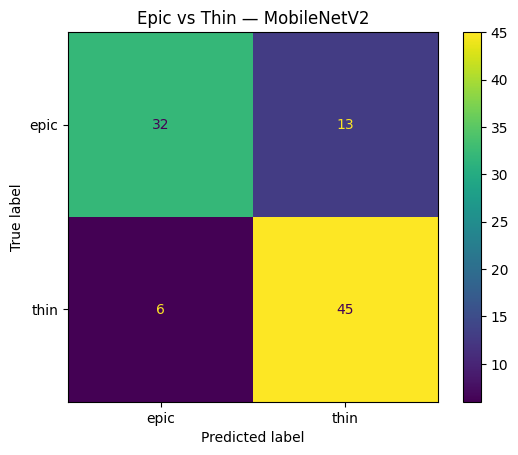

In [22]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = epic_model.predict(images, verbose=0).flatten()
    y_true.extend(labels.numpy().astype(int))
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_ds.class_names
)
disp.plot(values_format="d")
plt.title("Epic vs Thin — MobileNetV2")
plt.show()

## Spara modellen

In [23]:
import os
os.makedirs("models", exist_ok=True)
epic_model.save("models/epic_detector.keras")
print("Sparad!")

Sparad!
